In [3]:
import numpy as np
import matplotlib.pyplot as mplt
import pandas as pd
import os

current_path = os.getcwd()
print(current_path)

/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_impedance_measurement


In [5]:

path = os.path.join(current_path, "data", "manifest.csv")
data = pd.read_csv(path, sep=',')

In [6]:
# Some examples of how I can access the data in the DataFrame
# For example, to access the first row of the DataFrame:
first_row = data.iloc[0]
print("First row of the DataFrame:")
print(first_row)    
# To access a specific column, for example, the 'filename' column:
filename_column = data['filename']
print("\nFilename column:")
print(filename_column)  


First row of the DataFrame:
cfg_id                                                  0
filename      raw/imp_meas_gap_4_Deltaq_1_4_y0_1_0.pickle
gap_mm                                                4.0
delta_q_nC                                            1.4
y0_mm                                                 1.0
n_turns                                               200
n_acq                                                  20
Name: 0, dtype: object

Filename column:
0      raw/imp_meas_gap_4_Deltaq_1_4_y0_1_0.pickle
1      raw/imp_meas_gap_4_Deltaq_1_4_y0_1_5.pickle
2      raw/imp_meas_gap_4_Deltaq_1_4_y0_2_0.pickle
3      raw/imp_meas_gap_4_Deltaq_2_0_y0_1_0.pickle
4      raw/imp_meas_gap_4_Deltaq_2_0_y0_1_5.pickle
5      raw/imp_meas_gap_4_Deltaq_2_0_y0_2_0.pickle
6      raw/imp_meas_gap_4_Deltaq_2_6_y0_1_0.pickle
7      raw/imp_meas_gap_4_Deltaq_2_6_y0_1_5.pickle
8      raw/imp_meas_gap_4_Deltaq_2_6_y0_2_0.pickle
9     raw/imp_meas_gap_14_Deltaq_1_4_y0_1_0.pickle
10    raw/imp_m

In [7]:
# To access a specific value, for example, the filename of the first row:
first_filename = data.loc[0, 'filename']
print("\nFilename of the first row:")
print(first_filename)
# To display the first few rows of the DataFrame:
print("\nFirst few rows of the DataFrame:")
print(data.head())
# To display the last few rows of the DataFrame:
print("\nLast few rows of the DataFrame:")
print(data.tail())
# To display some arbitrary rows of the DataFrame, for example, rows 5 to 10:
print("\nRows 5 to 10 of the DataFrame:")
print(data.iloc[5:11])  # Note that the end index is exclusive, so we use 11 to include row 10
# To display some basic statistics about the DataFrame:
print("\nBasic statistics about the DataFrame:")
print(data.describe())



Filename of the first row:
raw/imp_meas_gap_4_Deltaq_1_4_y0_1_0.pickle

First few rows of the DataFrame:
   cfg_id                                     filename  gap_mm  delta_q_nC  \
0       0  raw/imp_meas_gap_4_Deltaq_1_4_y0_1_0.pickle     4.0         1.4   
1       1  raw/imp_meas_gap_4_Deltaq_1_4_y0_1_5.pickle     4.0         1.4   
2       2  raw/imp_meas_gap_4_Deltaq_1_4_y0_2_0.pickle     4.0         1.4   
3       3  raw/imp_meas_gap_4_Deltaq_2_0_y0_1_0.pickle     4.0         2.0   
4       4  raw/imp_meas_gap_4_Deltaq_2_0_y0_1_5.pickle     4.0         2.0   

   y0_mm  n_turns  n_acq  
0    1.0      200     20  
1    1.5      200     20  
2    2.0      200     20  
3    1.0      200     20  
4    1.5      200     20  

Last few rows of the DataFrame:
    cfg_id                                      filename  gap_mm  delta_q_nC  \
22      22  raw/imp_meas_gap_24_Deltaq_2_0_y0_1_5.pickle    24.0         2.0   
23      23  raw/imp_meas_gap_24_Deltaq_2_0_y0_2_0.pickle    24.0      

In [36]:
import numpy as np

import pyaccel
from pymodels import si

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [37]:
model = si.create_accelerator()

spos = pyaccel.lattice.find_spos(model, indices='open')
bpm_indices = pyaccel.lattice.find_indices(model, 'fam_name', 'BPM')
ivu_indices_all = pyaccel.lattice.find_indices(model, 'fam_name', 'IVU18')

In [38]:
print(spos.shape)
print(np.array(bpm_indices).shape)
print(np.array(ivu_indices_all).shape)

(6752,)
(160,)
(4,)


In [39]:
print(model)

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: SI_V25_04_1.21.3
lattice size   : 6752
lattice length : 518.3898999999917 m


In [12]:
cod_pos = pyaccel.tracking.find_orbit4(model, indices='open')
cod_pos.shape

(4, 6752)

In [ ]:
import os
import sys

utils_path = os.path.join(os.getcwd(), "utils")

if utils_path not in sys.path:
    sys.path.append(utils_path)

from ivu_orm import calc_ivu_orm


In [15]:
orm, info = calc_ivu_orm(delta_vkick=5e-6, ivu_number=1)


In [29]:
print(orm.shape)
print(info['spos_bpms'].shape)
n_bpms = len(info['spos_bpms'])
delta_vkick = info['delta_vkick']

(320,)
(160,)


In [20]:
import matplotlib.pyplot as mplt

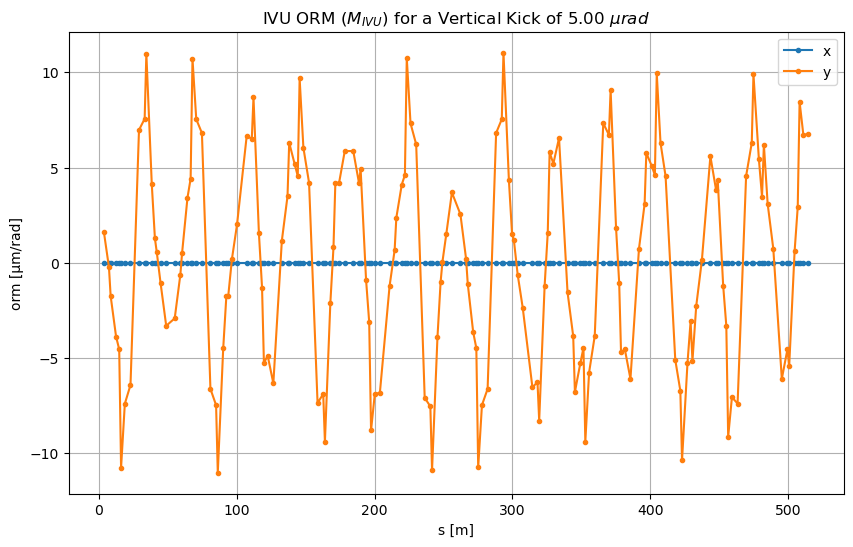

In [35]:
fig, ax = mplt.subplots(figsize=(10, 6))
ax.plot(info['spos_bpms'], orm[:n_bpms], '.-', label='x')
ax.plot(info['spos_bpms'], orm[n_bpms:], '.-', label='y')
ax.set_title(rf'IVU ORM ($M_{{IVU}}$) for a Vertical Kick of {delta_vkick*1e6:.2f} $\mu rad$')
ax.set_xlabel('s [m]')
ax.set_ylabel('orm [µm/rad]')
ax.legend()
ax.grid(True)
mplt.show()

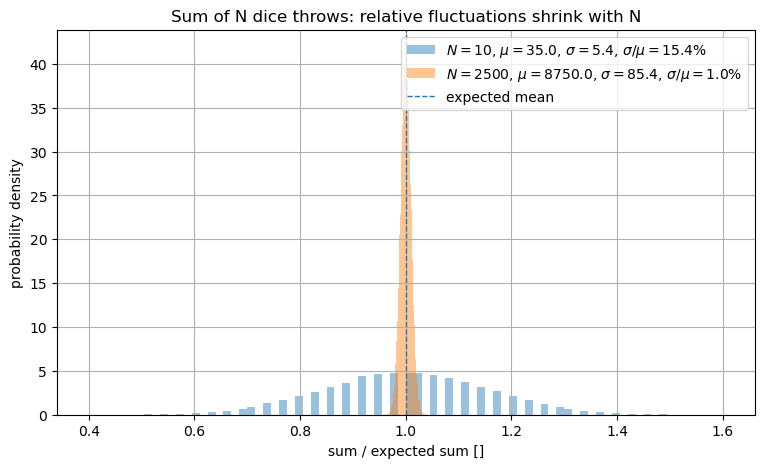

In [7]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_samples = 50_000
N_values = [10, 2500]

fig, ax = plt.subplots(figsize=(9, 5))

for N in N_values:
    sums = np.zeros(n_samples)

    for _ in range(N):
        sums += rng.integers(1, 7, size=n_samples)

    mean = 3.5 * N
    std = np.sqrt(N * 35 / 12)
    rel_std = std / mean

    relative_sum = sums / mean

    ax.hist(
        relative_sum,
        bins=80,
        density=True,
        alpha=0.45,
        label=(
            rf"$N={N}$, "
            rf"$\mu={mean:.1f}$, "
            rf"$\sigma={std:.1f}$, "
            rf"$\sigma/\mu={100*rel_std:.1f}\%$"
        ),
    )

ax.axvline(1.0, linestyle="--", linewidth=1, label="expected mean")
ax.set_title("Sum of N dice throws: relative fluctuations shrink with N")
ax.set_xlabel(r"sum / expected sum []")
ax.set_ylabel("probability density")
ax.grid(True)
ax.legend()
plt.show()

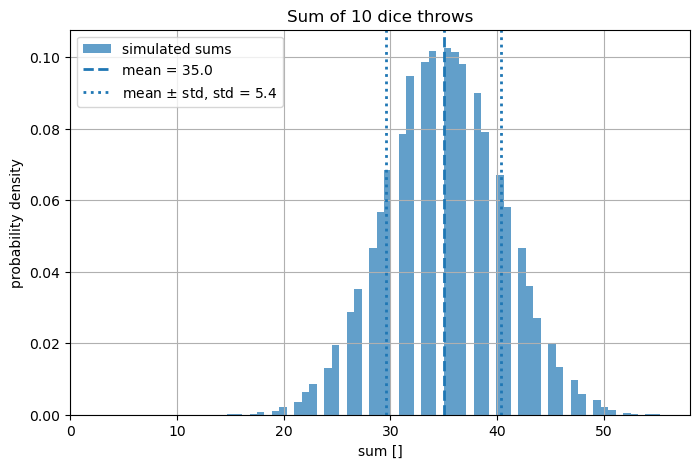

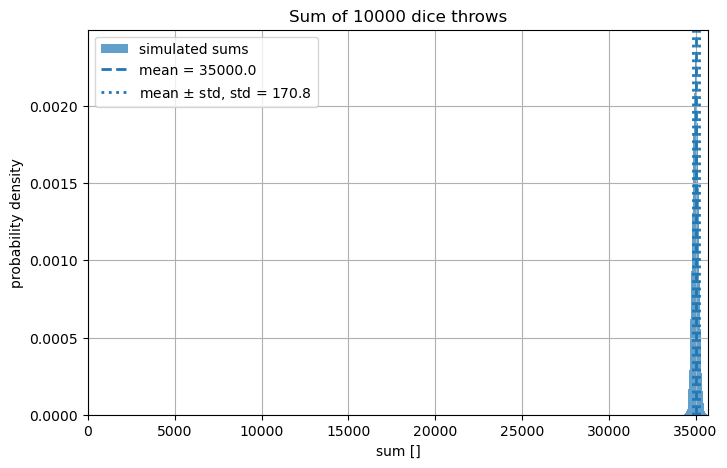

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_samples = 50_000
N_values = [10, 10000]

for N in N_values:
    sums = np.zeros(n_samples)

    for _ in range(N):
        sums += rng.integers(1, 7, size=n_samples)

    mean_theory = 3.5 * N
    std_theory = np.sqrt(N * 35 / 12)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        sums,
        bins=60,
        density=True,
        alpha=0.7,
        label="simulated sums",
    )

    ax.axvline(
        mean_theory,
        linestyle="--",
        linewidth=2,
        label=rf"mean = {mean_theory:.1f}",
    )

    ax.axvline(
        mean_theory - std_theory,
        linestyle=":",
        linewidth=2,
        label=rf"mean $\pm$ std, std = {std_theory:.1f}",
    )

    ax.axvline(
        mean_theory + std_theory,
        linestyle=":",
        linewidth=2,
    )

    ax.set_title(rf"Sum of {N} dice throws")
    ax.set_xlabel("sum []")
    ax.set_ylabel("probability density")
    ax.set_xlim(left=0)
    ax.grid(True)
    ax.legend()
    plt.show()